# 🔍 Exploratory Data Analysis: FMA Dataset

Este notebook explora en profundidad el dataset utilizado en la implementación de SemiSupCon:

- **FMA (Free Music Archive)** — Audio + metadatos de tracks

---

## 0. Setup

In [ ]:
import os
import zipfile
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import torchaudio
import librosa
import librosa.display
from IPython.display import Audio, display, HTML

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor': '#ffffff',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# ── Montar Google Drive ──
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = Path('/content/drive/MyDrive/my_paper_data')
DRIVE_BASE.mkdir(parents=True, exist_ok=True)

DATA_DIR = DRIVE_BASE

SR = 22050  # Target sample rate

def download_file(url, dest, desc=None):
    dest = Path(dest)
    if dest.exists():
        print(f'  ✓ Ya existe: {dest.name}')
        return
    print(f'  ↓ Descargando {desc or dest.name}...')
    def _p(bn, bs, ts):
        if ts > 0:
            print(f'\r    {min(100, bn*bs*100/ts):5.1f}% ({bn*bs/1024**2:.0f}/{ts/1024**2:.0f} MB)', end='', flush=True)
    urllib.request.urlretrieve(url, str(dest), _p)
    print(f'\n  ✓ Listo: {dest.name}')

print('Setup completo ✓')

Setup completo ✓


---

# FMA (Free Music Archive)

> **Paper**: Defferrard et al., *FMA: A Dataset For Music Analysis* (ISMIR 2017)  
> **URL**: https://github.com/mdeff/fma  
> **Subset small**: 8,000 tracks × 30s, 8 géneros balanceados, 7.2 GiB

## 1. Descarga de Metadatos y Audio

In [2]:
META_DIR = DATA_DIR / 'fma_metadata'
AUDIO_DIR = DATA_DIR / 'fma_small'

# Metadata
meta_zip = DATA_DIR / 'fma_metadata.zip'
download_file('https://os.unil.cloud.switch.ch/fma/fma_metadata.zip', meta_zip, 'FMA Metadata (342 MB)')
if not META_DIR.exists():
    print('  📦 Extrayendo metadata...')
    with zipfile.ZipFile(str(meta_zip)) as zf:
        zf.extractall(str(DATA_DIR))
    print('  ✓ Extraído')
else:
    print('  ✓ Metadata ya extraída')

# Audio
audio_zip = DATA_DIR / 'fma_small.zip'
download_file('https://os.unil.cloud.switch.ch/fma/fma_small.zip', audio_zip, 'FMA Small Audio (7.2 GB)')
if not AUDIO_DIR.exists():
    print('  📦 Extrayendo audio...')
    with zipfile.ZipFile(str(audio_zip)) as zf:
        zf.extractall(str(DATA_DIR))
    print('  ✓ Extraído')
else:
    print('  ✓ Audio ya extraído')

  ✓ Ya existe: fma_metadata.zip
  ✓ Metadata ya extraída
  ✓ Ya existe: fma_small.zip
  ✓ Audio ya extraído


## 2. Exploración de Archivos de Metadatos

FMA distribuye 4 archivos CSV principales:

In [3]:
print('=== Archivos en fma_metadata/ ===')
for f in sorted(META_DIR.iterdir()):
    size_mb = f.stat().st_size / 1024**2
    print(f'  {f.name:25s}  {size_mb:8.1f} MB')

=== Archivos en fma_metadata/ ===
  README.txt                      0.0 MB
  checksums                       0.0 MB
  echonest.csv                   42.0 MB
  features.csv                  907.1 MB
  genres.csv                      0.0 MB
  not_found.pickle                0.2 MB
  raw_albums.csv                 23.0 MB
  raw_artists.csv                13.4 MB
  raw_echonest.csv               46.4 MB
  raw_genres.csv                  0.0 MB
  raw_tracks.csv                116.6 MB
  tracks.csv                    248.4 MB


### 2.1 `tracks.csv` — Metadatos por track

In [4]:
# FMA tracks.csv tiene un header multi-nivel (2 niveles)
tracks = pd.read_csv(str(META_DIR / 'tracks.csv'), index_col=0, header=[0, 1])

print(f'Dimensiones: {tracks.shape[0]:,} tracks × {tracks.shape[1]} columnas')
print(f'\nÍndice: track_id (rango {tracks.index.min()} – {tracks.index.max()})')
print(f'\n{"="*60}')
print('COLUMNAS (nivel_0, nivel_1):')
print(f'{"="*60}')

# Mostrar todas las columnas agrupadas por nivel 0
for group in tracks.columns.get_level_values(0).unique():
    subcols = [c[1] for c in tracks.columns if c[0] == group]
    print(f'\n  📁 {group}:')
    for sc in subcols:
        dtype = tracks[(group, sc)].dtype
        non_null = tracks[(group, sc)].notna().sum()
        pct = non_null / len(tracks) * 100
        print(f'      {sc:25s}  {str(dtype):10s}  {non_null:>6,} non-null ({pct:.0f}%)')

Dimensiones: 106,574 tracks × 52 columnas

Índice: track_id (rango 2 – 155320)

COLUMNAS (nivel_0, nivel_1):

  📁 album:
      comments                   int64       106,574 non-null (100%)
      date_created               str         103,045 non-null (97%)
      date_released              str         70,294 non-null (66%)
      engineer                   str         15,295 non-null (14%)
      favorites                  int64       106,574 non-null (100%)
      id                         int64       106,574 non-null (100%)
      information                str         83,149 non-null (78%)
      listens                    int64       106,574 non-null (100%)
      producer                   str         18,060 non-null (17%)
      tags                       str         106,574 non-null (100%)
      title                      str         105,549 non-null (99%)
      tracks                     int64       106,574 non-null (100%)
      type                       str         100,066 non-null

In [50]:
# Vista previa de las primeras filas
print('=== Primeras 5 filas (columnas seleccionadas) ===')
preview_cols = [
    ('track', 'title'),
    ('artist', 'name'),
    ('track', 'genre_top'),
    ('track', 'genres'),
    ('track', 'bit_rate'),
    ('track', 'duration'),
    ('track', 'listens'),
    ('set', 'subset'),
    ('set', 'split')
]
existing_cols = [c for c in preview_cols if c in tracks.columns]
display(tracks[existing_cols].head(10))

=== Primeras 5 filas (columnas seleccionadas) ===


track      artist     track                      \
                        title        name genre_top     genres bit_rate   
track_id                                                                  
2                        Food        AWOL   Hip-Hop       [21]   256000   
3                Electric Ave        AWOL   Hip-Hop       [21]   256000   
5                  This World        AWOL   Hip-Hop       [21]   256000   
10                    Freeway   Kurt Vile       Pop       [10]   192000   
20            Spiritual Level  Nicky Cook       NaN  [76, 103]   256000   
26        Where is your Love?  Nicky Cook       NaN  [76, 103]   256000   
30                  Too Happy  Nicky Cook       NaN  [76, 103]   256000   
46                   Yosemite  Nicky Cook       NaN  [76, 103]   256000   
48             Light of Light  Nicky Cook       NaN  [76, 103]   256000   
134              Street Music        AWOL   Hip-Hop       [21]   256000   

                              set            
         duration listens  subset     split  
track_id                                     
2             168    1293   small  training  
3             237     514  medium  training  
5             206    1151   small  training  
10            161   50135   small  training  
20            311     361   large  training  
26            181     193   large  training  
30            174     612   large  training  
46            104     171   large  training  
48            205     173   large  training  
134           207     943  medium  training

In [6]:
# Distribución por subset
print('=== Distribución por Subset ===')
subset_counts = tracks[('set', 'subset')].value_counts()
for subset, count in subset_counts.items():
    print(f'  {subset:10s}: {count:>6,} tracks')

print(f'\n  Total:      {len(tracks):>6,} tracks')

=== Distribución por Subset ===
  large     : 81,574 tracks
  medium    : 17,000 tracks
  small     :  8,000 tracks

  Total:      106,574 tracks


In [7]:
# Filtrar solo el subset "small"
small = tracks[tracks[('set', 'subset')] == 'small'].copy()
print(f'FMA Small: {len(small):,} tracks')
print(f'\nSplit train/val/test:')
print(small[('set', 'split')].value_counts().to_string())

FMA Small: 8,000 tracks

Split train/val/test:
(set, split)
training      6400
validation     800
test           800


### 2.2 Distribución de Géneros (FMA Small)

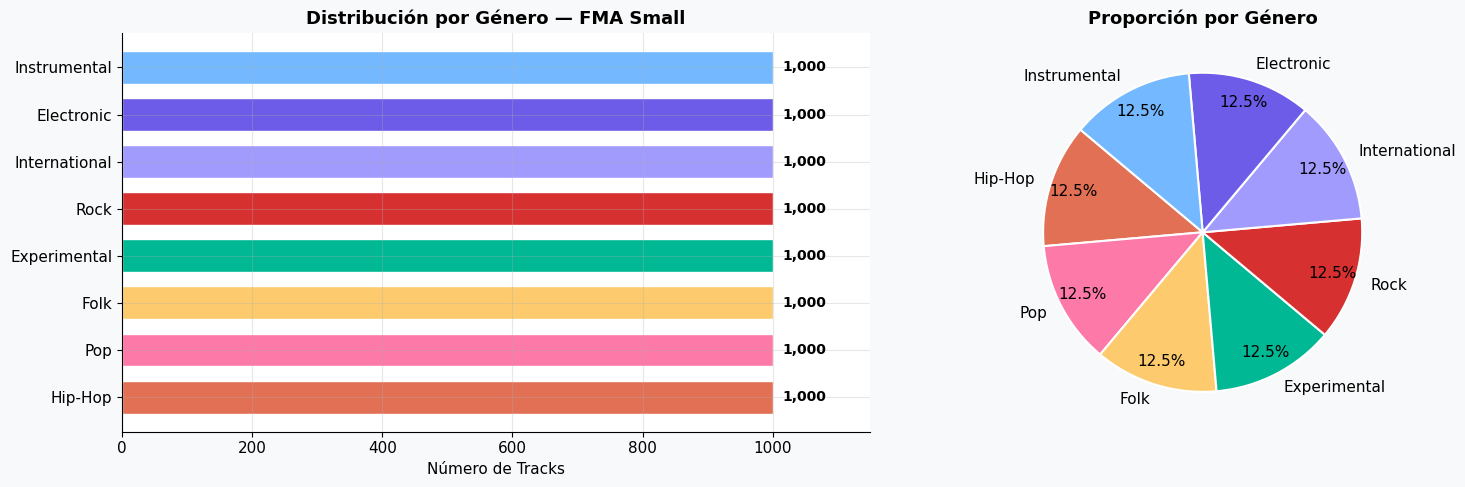


Total tracks con género: 8,000
Géneros únicos: 8
Tracks por género (promedio): 1,000


In [8]:
genres_col = small[('track', 'genre_top')].dropna()
genre_counts = genres_col.value_counts().sort_values(ascending=True)

# Colores por género
genre_colors = {
    'Electronic': '#6C5CE7',
    'Experimental': '#00B894',
    'Folk': '#FDCB6E',
    'Hip-Hop': '#E17055',
    'Instrumental': '#74B9FF',
    'International': '#A29BFE',
    'Pop': '#FD79A8',
    'Rock': '#D63031'
}
colors = [genre_colors.get(g, '#636e72') for g in genre_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
bars = axes[0].barh(genre_counts.index, genre_counts.values, color=colors, edgecolor='white', height=0.7)
for bar, val in zip(bars, genre_counts.values):
    axes[0].text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontweight='bold', fontsize=10)
axes[0].set_xlabel('Número de Tracks')
axes[0].set_title('Distribución por Género — FMA Small', fontweight='bold', fontsize=13)
axes[0].set_xlim(0, genre_counts.max() * 1.15)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Pie chart
axes[1].pie(genre_counts.values, labels=genre_counts.index, colors=colors,
            autopct='%1.1f%%', pctdistance=0.85, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporción por Género', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

print(f'\nTotal tracks con género: {len(genres_col):,}')
print(f'Géneros únicos: {genres_col.nunique()}')
print(f'Tracks por género (promedio): {len(genres_col) // genres_col.nunique():,}')

### 2.3 Estadísticas de Duración y Listens

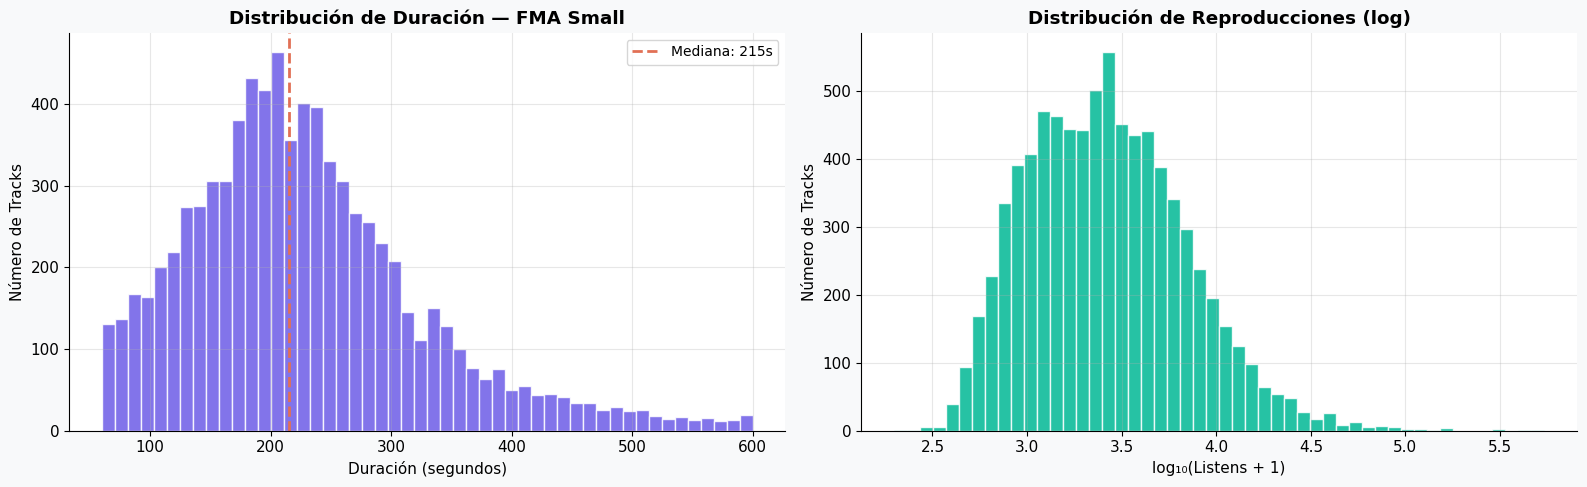

Duración — media: 228.8s, mediana: 215.0s, min: 60.0s, max: 600.0s
Listens  — media: 4730, mediana: 2492, max: 543,252


In [9]:
duration = small[('track', 'duration')].dropna().astype(float)
listens = small[('track', 'listens')].dropna().astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Duración
axes[0].hist(duration, bins=50, color='#6C5CE7', edgecolor='white', alpha=0.85)
axes[0].axvline(duration.median(), color='#E17055', linestyle='--', linewidth=2, label=f'Mediana: {duration.median():.0f}s')
axes[0].set_xlabel('Duración (segundos)')
axes[0].set_ylabel('Número de Tracks')
axes[0].set_title('Distribución de Duración — FMA Small', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Listens (log scale)
listens_pos = listens[listens > 0]
axes[1].hist(np.log10(listens_pos + 1), bins=50, color='#00B894', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('log₁₀(Listens + 1)')
axes[1].set_ylabel('Número de Tracks')
axes[1].set_title('Distribución de Reproducciones (log)', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Duración — media: {duration.mean():.1f}s, mediana: {duration.median():.1f}s, min: {duration.min():.1f}s, max: {duration.max():.1f}s')
print(f'Listens  — media: {listens.mean():.0f}, mediana: {listens.median():.0f}, max: {listens.max():,.0f}')

### 2.4 `genres.csv` — Jerarquía de Géneros

In [10]:
genres_df = pd.read_csv(str(META_DIR / 'genres.csv'))

print(f'Dimensiones: {genres_df.shape}')
print(f'\nColumnas: {list(genres_df.columns)}')
print(f'\nTotal géneros definidos: {len(genres_df)}')
print(f'Géneros top-level (parent=0): {(genres_df["parent"] == 0).sum()}')

display(genres_df.head(20))

Dimensiones: (163, 5)

Columnas: ['genre_id', '#tracks', 'parent', 'title', 'top_level']

Total géneros definidos: 163
Géneros top-level (parent=0): 16


,genre_id,#tracks,parent,title,top_level
0,1,8693,38,Avant-Garde,38
1,2,5271,0,International,2
2,3,1752,0,Blues,3
3,4,4126,0,Jazz,4
4,5,4106,0,Classical,5
5,6,914,38,Novelty,38
6,7,217,20,Comedy,20
7,8,868,0,Old-Time / Historic,8
8,9,1987,0,Country,9
9,10,13845,0,Pop,10


In [11]:
# Mostrar jerarquía de géneros (top-level y sus hijos)
top_genres = genres_df[genres_df['parent'] == 0].sort_values('title')

print('=== Jerarquía de Géneros FMA ===')
print(f'Total: {len(genres_df)} géneros, {len(top_genres)} top-level\n')

for _, row in top_genres.iterrows():
    gid = row['genre_id']
    children = genres_df[genres_df['parent'] == gid]
    tracks_count = row.get('#tracks', '?')
    print(f'🎵 {row["title"]} (id={gid}, tracks={tracks_count})')
    for _, child in children.head(8).iterrows():
        ct = child.get('#tracks', '?')
        print(f'   └─ {child["title"]} (tracks={ct})')
    if len(children) > 8:
        print(f'   └─ ... y {len(children)-8} sub-géneros más')
    print()

=== Jerarquía de Géneros FMA ===
Total: 163 géneros, 16 top-level

🎵 Blues (id=3, tracks=1752)
   └─ Gospel (tracks=66)

🎵 Classical (id=5, tracks=4106)
   └─ 20th Century Classical (tracks=292)
   └─ Composed Music (tracks=630)
   └─ Opera (tracks=161)
   └─ Chamber Music (tracks=170)
   └─ Choral Music (tracks=216)
   └─ Symphony (tracks=25)
   └─ Contemporary Classical (tracks=1239)

🎵 Country (id=9, tracks=1987)
   └─ Bluegrass (tracks=178)
   └─ Americana (tracks=994)
   └─ Rockabilly (tracks=128)
   └─ Country & Western (tracks=79)

🎵 Easy Listening (id=13, tracks=730)
   └─ Easy Listening: Vocal (tracks=47)
   └─ Lounge (tracks=440)
   └─ Nu-Jazz (tracks=120)

🎵 Electronic (id=15, tracks=34413)
   └─ Ambient Electronic (tracks=5723)
   └─ Techno (tracks=2140)
   └─ House (tracks=1482)
   └─ Glitch (tracks=2809)
   └─ Minimal Electronic (tracks=1013)
   └─ Breakcore - Hard (tracks=511)
   └─ IDM (tracks=3472)
   └─ Trip-Hop (tracks=1751)
   └─ ... y 6 sub-géneros más

🎵 Experimen

### 2.5 Multi-label: Géneros Múltiples por Track

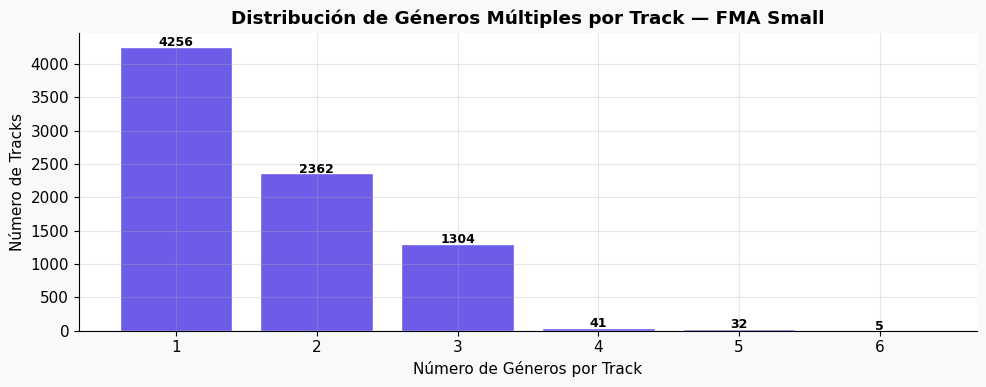

Tracks analizados: 8,000
Promedio géneros/track: 1.66
Máximo géneros/track: 6


In [12]:
# La columna 'genres' contiene una lista de IDs de género por track
import ast

genres_lists = small[('track', 'genres')].dropna()

def parse_genre_list(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

genres_parsed = genres_lists.apply(parse_genre_list)
n_genres_per_track = genres_parsed.apply(len)

fig, ax = plt.subplots(figsize=(10, 4))
counts = n_genres_per_track.value_counts().sort_index()
ax.bar(counts.index, counts.values, color='#6C5CE7', edgecolor='white')
ax.set_xlabel('Número de Géneros por Track')
ax.set_ylabel('Número de Tracks')
ax.set_title('Distribución de Géneros Múltiples por Track — FMA Small', fontweight='bold')
ax.set_xticks(counts.index)
for i, v in zip(counts.index, counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=9, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Tracks analizados: {len(n_genres_per_track):,}')
print(f'Promedio géneros/track: {n_genres_per_track.mean():.2f}')
print(f'Máximo géneros/track: {n_genres_per_track.max()}')

### 2.6 `features.csv` — Features Extraídas con Librosa

In [13]:
features = pd.read_csv(str(META_DIR / 'features.csv'), index_col=0, header=[0, 1, 2], nrows=5)

print(f'Features disponibles (groups):')
feat_groups = features.columns.get_level_values(0).unique()
for fg in feat_groups:
    sub = features.columns.get_level_values(1)[features.columns.get_level_values(0) == fg].unique()
    n_cols = (features.columns.get_level_values(0) == fg).sum()
    print(f'  📊 {fg:25s}  {n_cols:4d} features  (stats: {", ".join(sub[:5])})')

# Load full features for small subset only
features_full = pd.read_csv(str(META_DIR / 'features.csv'), index_col=0, header=[0, 1, 2])
features_small = features_full.loc[features_full.index.isin(small.index)]

print(f'\nFeatures para FMA Small: {features_small.shape}')
print(f'Total columnas de features: {features_small.shape[1]}')

Features disponibles (groups):
  📊 chroma_cens                  84 features  (stats: kurtosis, max, mean, median, min)
  📊 chroma_cqt                   84 features  (stats: kurtosis, max, mean, median, min)
  📊 chroma_stft                  84 features  (stats: kurtosis, max, mean, median, min)
  📊 mfcc                        140 features  (stats: kurtosis, max, mean, median, min)
  📊 rmse                          7 features  (stats: kurtosis, max, mean, median, min)
  📊 spectral_bandwidth            7 features  (stats: kurtosis, max, mean, median, min)
  📊 spectral_centroid             7 features  (stats: kurtosis, max, mean, median, min)
  📊 spectral_contrast            49 features  (stats: kurtosis, max, mean, median, min)
  📊 spectral_rolloff              7 features  (stats: kurtosis, max, mean, median, min)
  📊 tonnetz                      42 features  (stats: kurtosis, max, mean, median, min)
  📊 zcr                           7 features  (stats: kurtosis, max, mean, median, min)



## 3. Exploración de Audio

Visualización y reproducción de muestras de audio por género.

In [14]:
def get_audio_path(track_id):
    """Construye el path al archivo MP3 de FMA."""
    tid = str(track_id).zfill(6)
    return AUDIO_DIR / tid[:3] / f'{tid}.mp3'


def load_audio(track_id, sr=SR, duration=None):
    """Carga audio de un track ID."""
    path = get_audio_path(track_id)
    if not path.exists():
        return None, sr
    y, sr_out = librosa.load(str(path), sr=sr, mono=True, duration=duration)
    return y, sr_out


# Verificar cuántos archivos de audio existen realmente
audio_files = list(AUDIO_DIR.rglob('*.mp3'))
print(f'Archivos MP3 encontrados: {len(audio_files):,}')

# Muestra por género
print(f'\n=== Muestra de tracks por género ===')
for genre in sorted(genres_col.unique()):
    genre_tracks = small[small[('track', 'genre_top')] == genre]
    sample_id = genre_tracks.index[0]
    title = genre_tracks.loc[sample_id, ('track', 'title')] if ('track', 'title') in genre_tracks.columns else '?'
    artist = genre_tracks.loc[sample_id, ('artist', 'name')] if ('artist', 'name') in genre_tracks.columns else '?'
    path = get_audio_path(sample_id)
    exists = '✓' if path.exists() else '✗'
    print(f'  {genre:15s} | ID {sample_id:>6} | {exists} | {artist} — {title}')

Archivos MP3 encontrados: 8,000

=== Muestra de tracks por género ===
  Electronic      | ID   1482 | ✓ | Rainbro — Reindeer Dance
  Experimental    | ID    148 | ✓ | Contradiction — Blackout 2
  Folk            | ID    140 | ✓ | Alec K. Redfearn & the Eyesores — Queen Of The Wires
  Hip-Hop         | ID      2 | ✓ | AWOL — Food
  Instrumental    | ID  10250 | ✓ | JayDee — Tree Symphony
  International   | ID    666 | ✓ | Explode Into Colors — Heat
  Pop             | ID     10 | ✓ | Kurt Vile — Freeway
  Rock            | ID    182 | ✓ | Ariel Pink's Haunted Graffiti — Jules Lost His Jewels


In [15]:
# ── Reproducir una muestra de cada género ──
print('🎧 Muestras de Audio por Género (primeros 10 segundos)\n')

for genre in sorted(genres_col.unique()):
    genre_tracks = small[small[('track', 'genre_top')] == genre]
    # Buscar un track que exista
    for sample_id in genre_tracks.index[:10]:
        path = get_audio_path(sample_id)
        if path.exists():
            break
    else:
        print(f'{genre}: No se encontró audio')
        continue
    
    y, _ = load_audio(sample_id, sr=SR, duration=10)
    if y is None:
        continue
    
    title = genre_tracks.loc[sample_id, ('track', 'title')] if ('track', 'title') in genre_tracks.columns else '?'
    artist = genre_tracks.loc[sample_id, ('artist', 'name')] if ('artist', 'name') in genre_tracks.columns else '?'
    
    display(HTML(f'<b>🎵 {genre}</b> — {artist} – <i>{title}</i> (ID: {sample_id})'))
    display(Audio(data=y, rate=SR))
    print()

🎧 Muestras de Audio por Género (primeros 10 segundos)



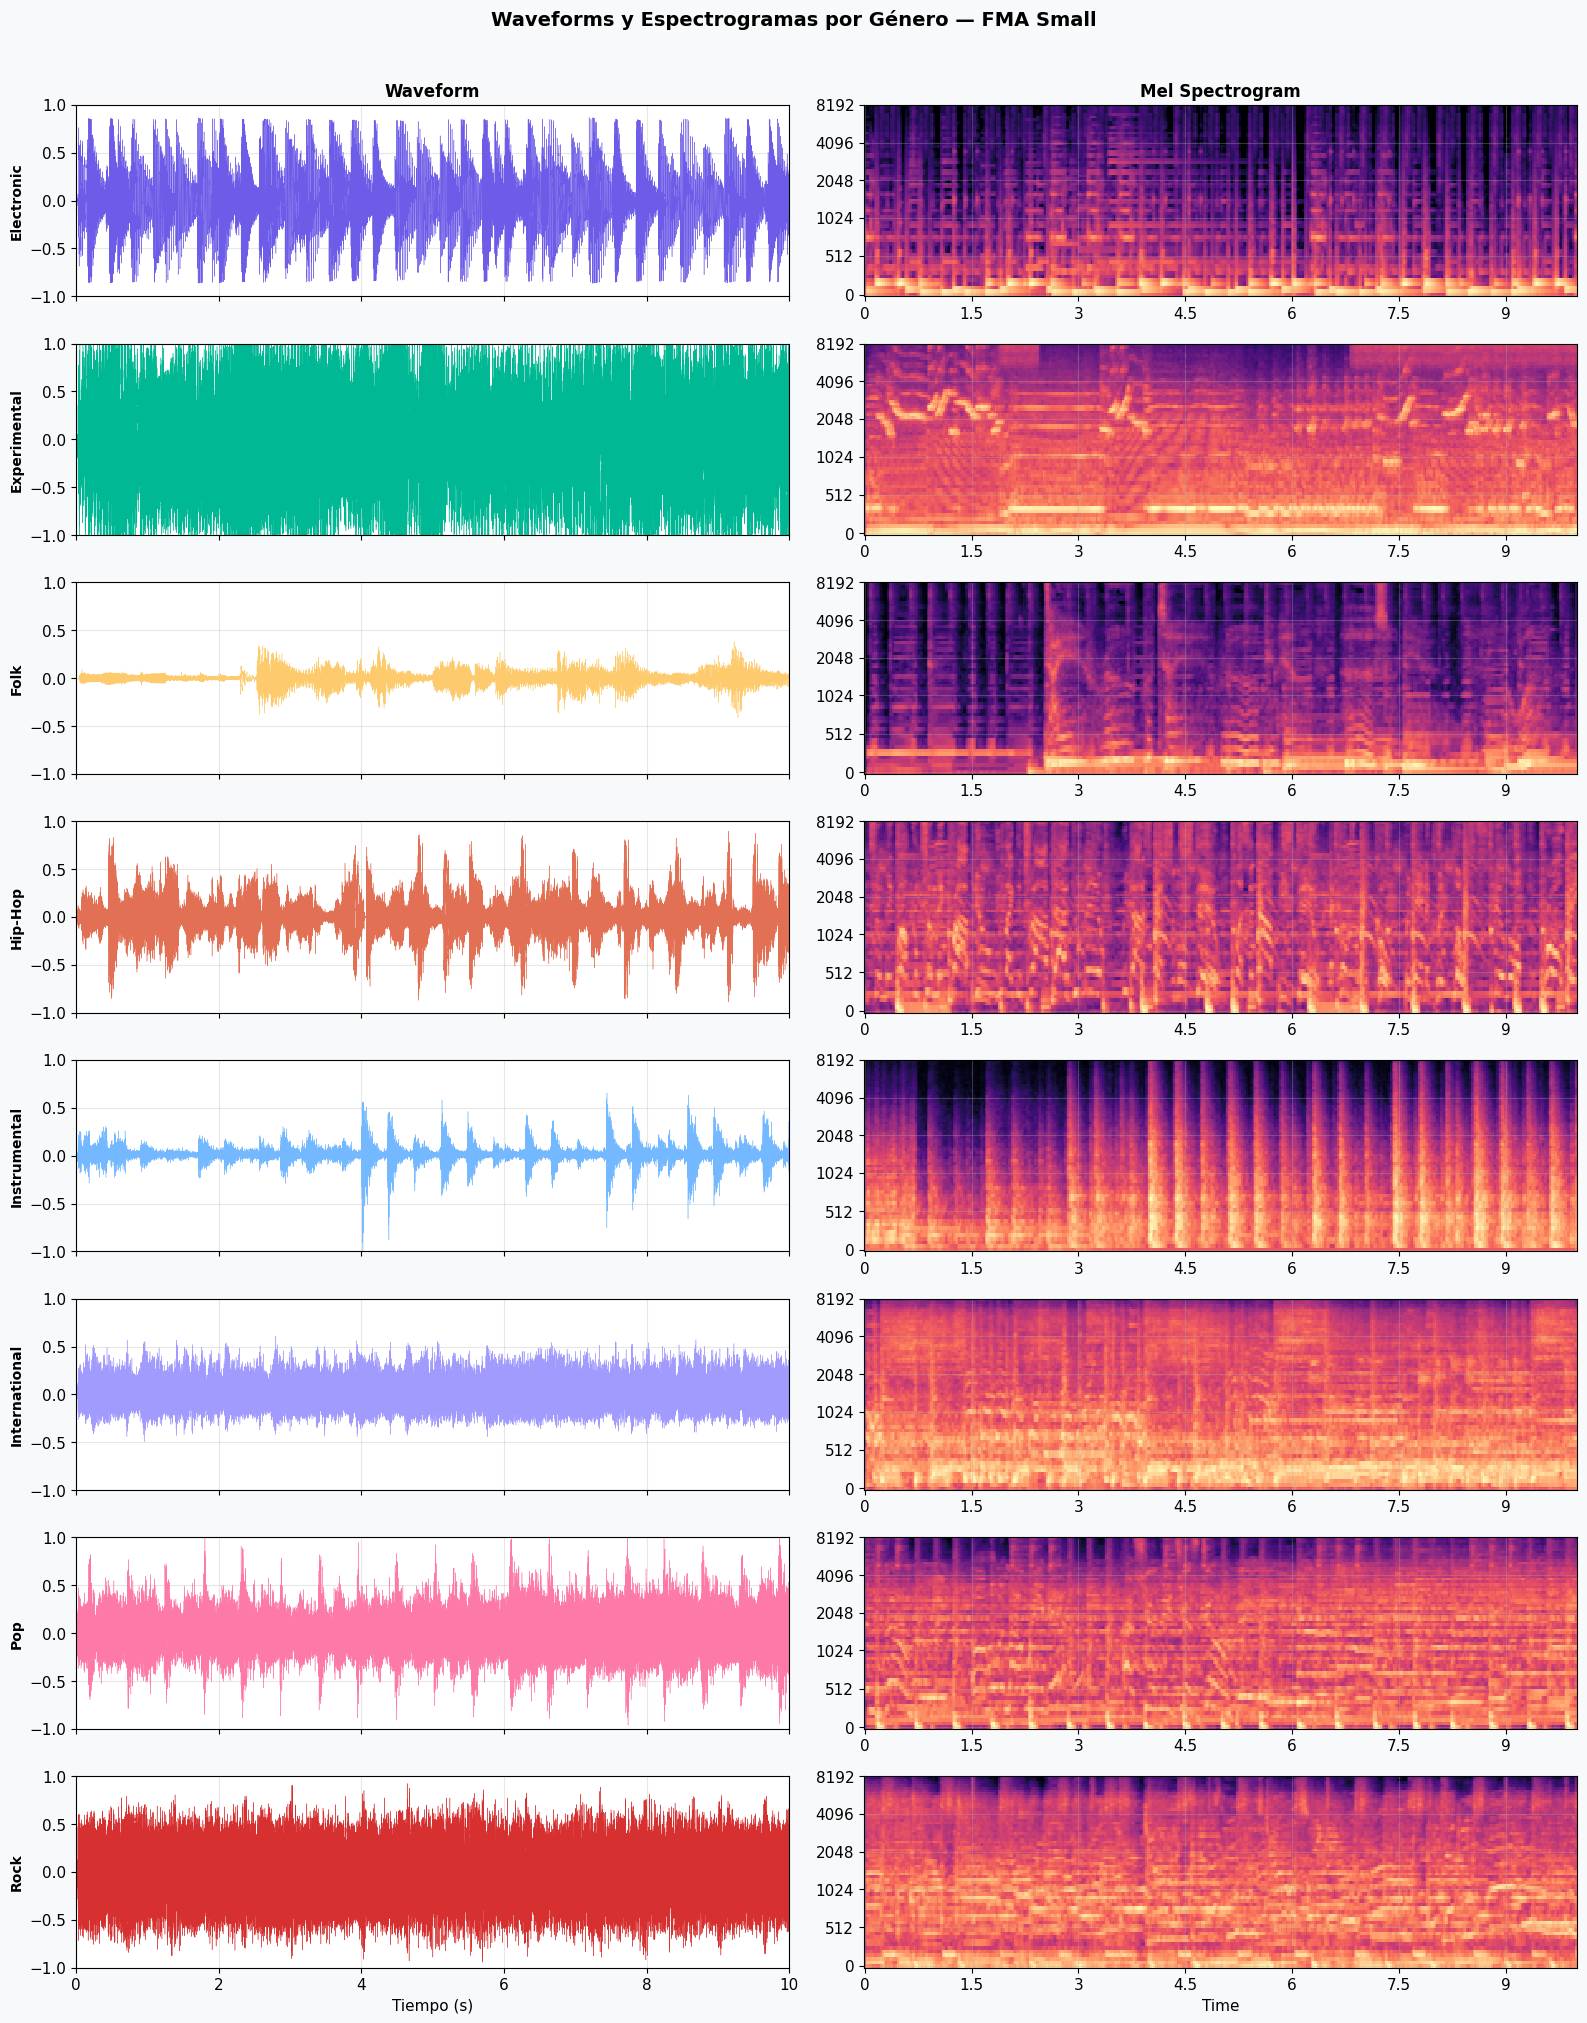

In [16]:
# ── Waveforms y Espectrogramas por género ──
genre_list = sorted(genres_col.unique())
n_genres = len(genre_list)

fig, axes = plt.subplots(n_genres, 2, figsize=(16, n_genres * 2.5))

for i, genre in enumerate(genre_list):
    genre_tracks = small[small[('track', 'genre_top')] == genre]
    
    for sample_id in genre_tracks.index[:10]:
        if get_audio_path(sample_id).exists():
            break
    
    y, _ = load_audio(sample_id, sr=SR, duration=10)
    if y is None:
        continue
    
    color = genre_colors.get(genre, '#636e72')
    
    # Waveform
    times = np.arange(len(y)) / SR
    axes[i, 0].plot(times, y, linewidth=0.3, color=color)
    axes[i, 0].set_ylabel(genre, fontweight='bold', fontsize=10)
    axes[i, 0].set_xlim(0, 10)
    axes[i, 0].set_ylim(-1, 1)
    if i == 0:
        axes[i, 0].set_title('Waveform', fontweight='bold', fontsize=12)
    if i < n_genres - 1:
        axes[i, 0].set_xticklabels([])
    else:
        axes[i, 0].set_xlabel('Tiempo (s)')
    
    # Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=64, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=SR, x_axis='time', y_axis='mel',
                            ax=axes[i, 1], cmap='magma', fmax=8000)
    if i == 0:
        axes[i, 1].set_title('Mel Spectrogram', fontweight='bold', fontsize=12)
    axes[i, 1].set_ylabel('')
    if i < n_genres - 1:
        axes[i, 1].set_xlabel('')

plt.suptitle('Waveforms y Espectrogramas por Género — FMA Small',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

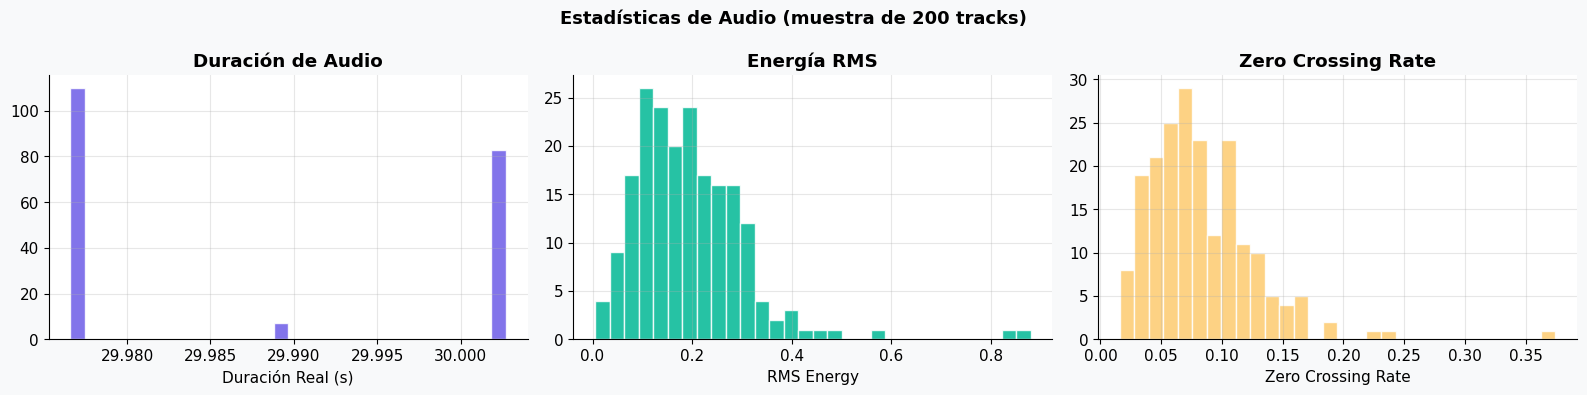

Duración — media: 30.0s, mediana: 30.0s
RMS      — media: 0.1948, max: 0.8792
ZCR      — media: 0.0833


In [17]:
# ── Estadísticas de audio ──
import random
random.seed(42)

sample_ids = random.sample(list(small.index), min(200, len(small)))
durations_real = []
rms_values = []
zcr_values = []

for tid in sample_ids:
    path = get_audio_path(tid)
    if not path.exists():
        continue
    try:
        y, _ = load_audio(tid, sr=SR)
        durations_real.append(len(y) / SR)
        rms_values.append(float(np.sqrt(np.mean(y**2))))
        zcr_values.append(float(np.mean(librosa.feature.zero_crossing_rate(y=y))))
    except:
        pass

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(durations_real, bins=30, color='#6C5CE7', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Duración Real (s)')
axes[0].set_title('Duración de Audio', fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].hist(rms_values, bins=30, color='#00B894', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('RMS Energy')
axes[1].set_title('Energía RMS', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

axes[2].hist(zcr_values, bins=30, color='#FDCB6E', edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Zero Crossing Rate')
axes[2].set_title('Zero Crossing Rate', fontweight='bold')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle(f'Estadísticas de Audio (muestra de {len(durations_real)} tracks)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Duración — media: {np.mean(durations_real):.1f}s, mediana: {np.median(durations_real):.1f}s')
print(f'RMS      — media: {np.mean(rms_values):.4f}, max: {np.max(rms_values):.4f}')
print(f'ZCR      — media: {np.mean(zcr_values):.4f}')

In [ ]:
# ── Resumen final ──
print('╔══════════════════════════════════════════════════════════════╗')
print('║              RESUMEN: FMA Small                              ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Tracks:          {len(small):>6,}                                   ║')
print(f'║  Géneros top:     {genres_col.nunique():>6}                                   ║')
print(f'║  Géneros total:   {len(genres_df):>6}                                   ║')
print(f'║  Duración:        ~30s por track                           ║')
print(f'║  Formato:         MP3 128kbps                              ║')
print(f'║  Features:        {features_small.shape[1]:>6} columnas pre-extraídas            ║')
print(f'╠══════════════════════════════════════════════════════════════╣')
print(f'║  USO EN SEMISUPCON                                          ║')
print(f'║  Los géneros nativos de FMA se usan como señal supervisada  ║')
print(f'║  para construir la contrastive matrix M.                    ║')
print(f'╚══════════════════════════════════════════════════════════════╝')